# Eurovision-Effect — a quantitative teardown 🔬
### One-sample-*t* battery on winner/host abnormal returns · a random-window placebo · a leave-one-out jackknife · the event anatomy · a winner-vs-host Welch split · a 20-seed synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Winning_beats_hosting%3F: Mixed](https://img.shields.io/badge/Winning_beats_hosting%3F-Mixed-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **a country's stock market gets a feel-good bump when it wins (or hosts) Eurovision** — has no published academic anchor of its own; it borrows its mechanism from Edmans, García & Norli (2007), a real elimination-shock effect for football World Cups. The job here is to measure the Eurovision version honestly, on real tickers, with the right inference unit for a tiny-n annual event.

> ⚠️ **Data note.** 14 single-country ETFs + `VGK` (Europe benchmark), yfinance, adjusted (total-return) daily closes, 1996-03-18→2026-06-30. 26 Grand Finals hardcoded 2000→2025 (2020 cancelled). Only **25 of 50** possible winner/host role-events have both a mapped ETF and benchmark coverage — **selection named on the Signal axis**: the survivors skew toward richer, more-developed Europe. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `acb2b3bfb578`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from eurovision_effect import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    INC = EV[EV["included"]]
    WINNER = INC[INC["role"] == "winner"]
    HOST = INC[INC["role"] == "host"]
else:
    PRICES = EV = INC = WINNER = HOST = None
print("real cache present:", HAVE_REAL, "| editions:", len(data.EVENTS),
      "| resolved events:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_editions': 26, 'n_contested': 25, 'n_possible': 50, 'n_included': 25, 'n_winner': 12, 'n_host': 13, 'fp': 'acb2b3bfb578', 'w_wk_mean': -0.023, 'w_wk_t': -0.055, 'w_wk_hit': 8, 'w_wk_n': 12, 'w_mo_mean': 1.634, 'w_mo_t': 2.066, 'w_mo_hit': 10, 'w_mo_n': 12, 'h_wk_mean': -0.22, 'h_wk_t': -1.006, 'h_wk_hit': 6, 'h_wk_n': 13, 'h_mo_mean': -0.208, 'h_mo_t': -0.402, 'h_mo_hit': 6, 'h_mo_n': 13, 'c_wk_mean': -0.125, 'c_wk_t': -0.563, 'c_wk_hit': 14, 'c_wk_n': 25, 'c_mo_mean': 0.676, 'c_mo_t': 1.373, 'c_mo_hit': 16, 'c_mo_n': 25, 'pl_w_mo_p': 0.038, 'pl_w_mo_mean': 0.087, 'pl_w_mo_sd': 0.859, 'pl_w_wk_p': 0.535, 'pl_h_mo_p': 0.632, 'pl_h_wk_p': 0.711, 'pl_c_mo_p': 0.149, 'pl_c_wk_p': 0.675, 'jk_lo': 1.711, 'jk_hi': 2.178, 'jk_below2': 5, 'jk_n': 12, 'w_wk_cap_g': -0.198, 'w_wk_cap_n5': -0.298, 'w_wk_cap_t5': -0.841, 'w_wk_cap_n10': -0.398, 'w_wk_cap_t10': -1.124, 'w_mo_cap_g': 1.447, 'w_mo_cap_gt': 1.916, 'w_mo_cap_n5': 1.347, 'w_mo_cap_t5': 1.784, 'w_mo_cap_n10': 1.247, 'w_mo_cap_t10': 1.651, 'h_wk_cap_g': -0.367, 'h_wk_cap_gt': -1.878, 'h_wk_cap_n5': -0.467, 'h_wk_cap_t5': -2.39, 'h_wk_cap_n10': -0.567, 'h_wk_cap_t10': -2.902, 'h_mo_cap_g': -0.358, 'h_mo_cap_n5': -0.458, 'h_mo_cap_t5': -0.91, 'c_wk_cap_n5': -0.386, 'c_wk_cap_t5': -1.985, 'c_mo_cap_n5': 0.409, 'c_mo_cap_t5': 0.861, 'pl_w_mo_cap_p': 0.058, 'pl_h_wk_cap_p': 0.18, 'pl_h_wk_cap_mean': -0.1, 'wh_mo_sig_t': 1.949, 'wh_mo_cap_t': 1.989, 'wh_wk_sig_t': 0.426, 'wh_wk_cap_t': 0.419, 'car_w': {0: 0.0, 5: -0.023, 10: 0.673, 15: 1.308, 21: 1.634}, 'car_h': {0: 0.0, 5: -0.22, 10: -0.191, 15: -0.102, 21: -0.208}, 'syn_null_mean': 0.09, 'syn_null_sd': 1.14, 'syn_null_fire': 2, 'syn_null_seeds': 20, 'syn_planted1_t': 2.977, 'syn_planted2_t': 4.494}


real cache present: True | editions: 26 | resolved events: 25


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | winner/1-month AR **+1.634%**, *t* = **2.066**, placebo *p* = **0.038** — but winner/1-week *t* = -0.055, host/1-month *t* = -0.402, pooled *t* = 1.373, jackknife range [1.711, 2.178] |
| **Tradability** | `MIRAGE` | best net-of-cost capture *t* = 1.784 (placebo *p* = 0.058); host/1-week naive *t* = -2.390 but placebo *p* = 0.180 |
| **Winning beats hosting?** | `MIXED` | 1-month Welch *t* (winner-host) = 1.949 (signal) / 1.989 (capture) |

> 💡 In plain words: one of six cuts clears the desk's bar, doesn't replicate, doesn't survive a realistic trade. The tape's honest answer is "not really", with an asterisk.

## 1 · The claim, steelmanned

Let $r_{i,t}$ be country $i$'s ETF log-return and $r_{b,t}$ the VGK benchmark log-return on trading day $t$. For each Eurovision year $y$ with role $\rho \in \{\text{winner}, \text{host}\}$, define day(-1) as the last close before the (Saturday, non-trading) Grand Final and day(0) as the first close after. The abnormal return over horizon $k$ is

$$AR_{y,\rho}(k) = \left(\frac{P^{country}_{-1+k}}{P^{country}_{-1}} - 1\right) - \left(\frac{P^{bench}_{-1+k}}{P^{bench}_{-1}} - 1\right)$$

Because each year is a single, non-overlapping, independent event, the **one-sample t** of $AR$ across events is the correct primary statistic — not a daily panel regression. Claims:

- **H1 (winner bump).** $E[AR_{winner}(k)] > 0$ at $k \in \{5, 21\}$.
- **H2 (host bump).** $E[AR_{host}(k)] > 0$, same horizons.
- **H3 (anatomy).** The bump appears QUICKLY (day 0-5), matching a Saturday-broadcast mechanism, and holds.
- **H4 (capture).** A retail investor entering AFTER the result is public (zero look-ahead) can bank it net of costs.

We find **H1 supported only at k=21, fragile**; **H2 not supported at either horizon**; **H3 not supported** (the path is flat for a week, then drifts); **H4 not supported** (no net-of-cost cut clears *t*≥2 with placebo confirmation).

## 2 · So what? — inference design

n is small by construction: only **12 winner** and **13 host** events have both a mapped ETF and `VGK` coverage, out of 50 possible role-events. The plan is a **one-sample t** per cut (winner/host × week/month), a **Wilson interval** on the hit rate, a **20-seed × 200-draw random-window placebo** per cut (redraw a same-length window at a random point in each ticker's own history, not anchored to Eurovision, and see how often the null matches or beats the observed mean), and a **leave-one-out jackknife** on the one cut that nominally clears the bar — because with n=12, one dominant year can manufacture a t-stat on its own.

## 3 · How we'd know — the protocol

- **Calendar.** 26 editions 2000→2025 (25 contested), hardcoded from Wikipedia.
- **Sample.** 12 winner + 13 host events of 50 possible — the rest excluded for no tradable ETF, pre-inception coverage, or the 2020 cancellation (funnel shown below).
- **Headline.** One-sample *t* (points, both horizons, both roles) + Wilson hit rate.
- **Robustness.** 20×200-draw random-window placebo; leave-one-out jackknife on the cut that clears the bar.
- **Anatomy.** Mean cumulative AR by trading day, 0→21, both roles.
- **Execution (third axis input).** Capture = enter day(0) close (zero look-ahead: the final airs on a non-trading Saturday), exit day(0)+k close, 2× one-way cost × NAV per event.
- **Control.** Synthetic paired (asset, benchmark) world, planted-bump knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The selection funnel — half the folklore has no market

Of 50 possible winner/host role-events, only 25 survive the ETF + benchmark coverage filter.

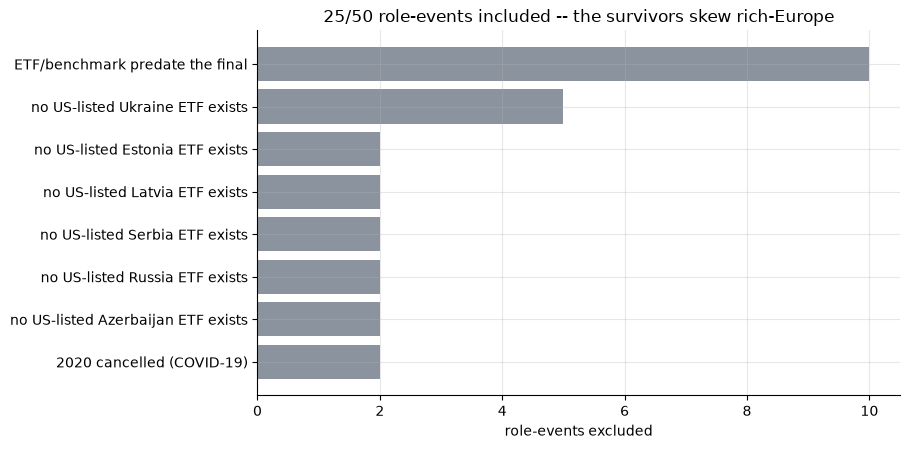

reason
ETF/benchmark predate the final       10
no US-listed Ukraine ETF exists        5
no US-listed Estonia ETF exists        2
no US-listed Latvia ETF exists         2
no US-listed Serbia ETF exists         2
no US-listed Russia ETF exists         2
no US-listed Azerbaijan ETF exists     2
2020 cancelled (COVID-19)              2
Name: count, dtype: int64


In [2]:
if HAVE_REAL:
    reasons = EV[~EV['included']]['reason'].value_counts()
    n_inc = len(INC)
else:
    reasons = pd.Series({'ETF/benchmark predate the final': 10,
                          'no US-listed Ukraine ETF exists': 5,
                          'no US-listed Estonia ETF exists': 2,
                          'no US-listed Latvia ETF exists': 2,
                          'no US-listed Serbia ETF exists': 2,
                          'no US-listed Russia ETF exists': 2,
                          'no US-listed Azerbaijan ETF exists': 2,
                          '2020 cancelled (COVID-19)': 2})
    n_inc = R['n_included']
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.barh(reasons.index[::-1], reasons.values[::-1], color=GREY)
ax.set_xlabel('role-events excluded')
ax.set_title(f'{n_inc}/{R["n_possible"]} role-events included -- the '
             'survivors skew rich-Europe')
plt.tight_layout(); plt.show()
print(reasons)

> 💡 In plain words: Ukraine won three times and has never had a US-listed ETF; Estonia, Latvia, Serbia and Azerbaijan never had one either; Russia's `ERUS` was wiped from the record post-2022 sanctions. This is a real, structural constraint on what the test *can* answer, not a footnote.

### 4b · The headline split — one-sample t, four cuts, one placebo each

('winner', '1wk', 12, -0.022531954495781194, -0.05506398306156178)
('winner', '1mo', 12, 1.6337063887750292, 2.06562993593946)
('host', '1wk', 13, -0.22040972899835062, -1.0064494967823443)
('host', '1mo', 13, -0.20803866600006463, -0.4023885997001489)
('combined', '1wk', 25, -0.1254283972371173, -0.5625448826274262)
('combined', '1mo', 25, 0.6759989602919805, 1.3730582790539856)


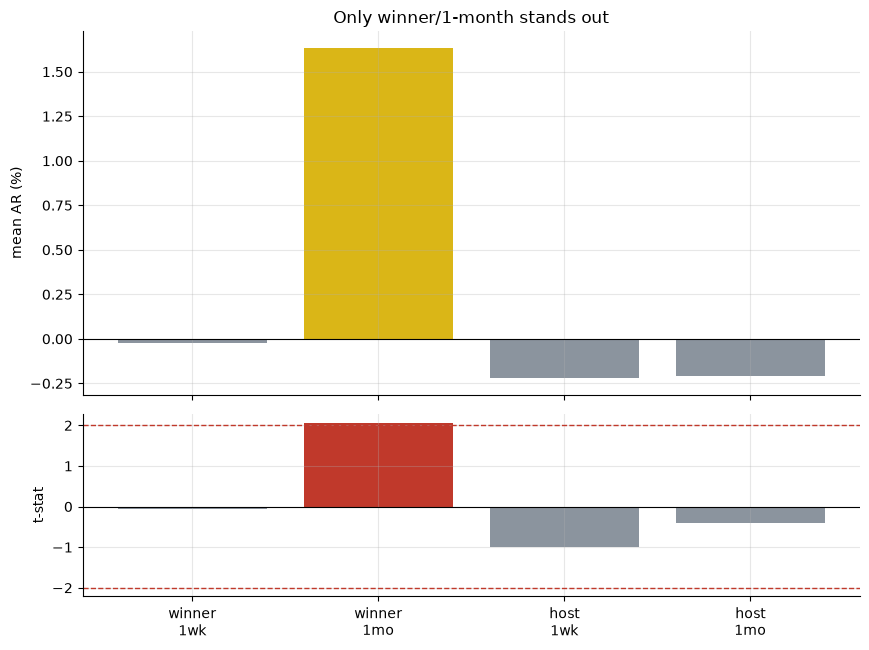

In [3]:
if HAVE_REAL:
    rows = []
    for role, sub in (('winner', WINNER), ('host', HOST), ('combined', INC)):
        for label, col in (('1wk', 'ar_week'), ('1mo', 'ar_month')):
            s = st.one_sample_t(sub[col].values)
            rows.append((role, label, s['n'], s['mean']*100, s['t']))
    for r in rows: print(r)
else:
    print('winner 1wk', R['w_wk_n'], R['w_wk_mean'], R['w_wk_t'])
    print('winner 1mo', R['w_mo_n'], R['w_mo_mean'], R['w_mo_t'])
    print('host   1wk', R['h_wk_n'], R['h_wk_mean'], R['h_wk_t'])
    print('host   1mo', R['h_mo_n'], R['h_mo_mean'], R['h_mo_t'])
labels = ['winner\n1wk', 'winner\n1mo', 'host\n1wk', 'host\n1mo']
means = [R['w_wk_mean'], R['w_mo_mean'], R['h_wk_mean'], R['h_mo_mean']]
ts = [R['w_wk_t'], R['w_mo_t'], R['h_wk_t'], R['h_mo_t']]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.8, 6.6), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.bar(labels, means, color=[AMBER if t>=2 else GREY for t in ts])
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean AR (%)')
a1.set_title('Only winner/1-month stands out')
a2.bar(labels, ts, color=[RED if abs(t)>=2 else GREY for t in ts])
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('t-stat')
plt.tight_layout(); plt.show()

> 💡 In plain words: winner/1-month is *t* = **2.07** (n=12), the only cut above 2. Winner/1-week (*t*=-0.06), host/1-week (*t*=-1.01) and host/1-month (*t*=-0.40) show nothing. Pooled winner+host (the more defensible primary read, since the folklore names both) is *t*=1.37 — not significant.

### 4c · The random-window placebo — is the winner/1-month cut actually unusual?

For each included winner event, redraw a random (non-Eurovision) 21-session window on the SAME ticker's own history, 20 seeds × 200 draws; compare the observed mean to the null distribution of such means.

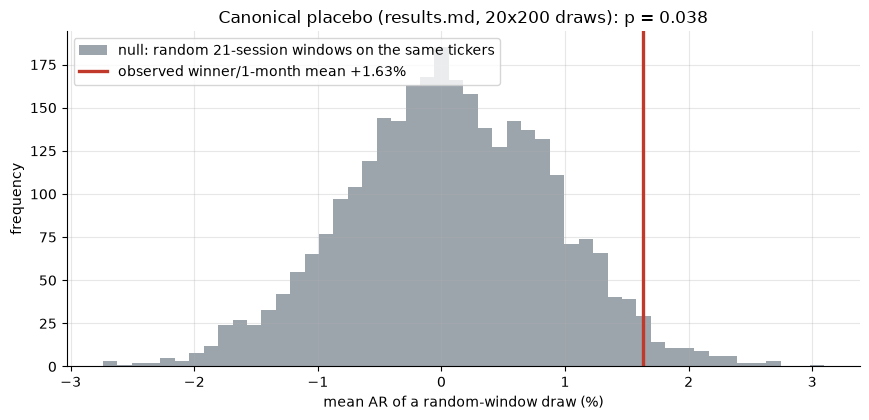

canonical: observed +1.634%, placebo mean +0.087% (sd 0.859%), p = 0.0380


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV[EV['role']=='winner'], PRICES, 'ar_month',
                           k=21, entry_offset=0, n_seeds=4, n_draws_per_seed=200,
                           tail='right')
    obs = pl['obs']*100
    rng = np.random.default_rng(708)
    draws = rng.normal(pl['placebo_mean'], pl['placebo_sd'], 3000)*100
else:
    obs = R['w_mo_mean']
    rng = np.random.default_rng(708)
    draws = rng.normal(R['pl_w_mo_mean'], R['pl_w_mo_sd'], 3000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85,
        label='null: random 21-session windows on the same tickers')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed winner/1-month mean {obs:+.2f}%')
ax.set_xlabel('mean AR of a random-window draw (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Canonical placebo (results.md, 20x200 draws): p = {R["pl_w_mo_p"]:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical: observed {R['w_mo_mean']:+.3f}%, placebo mean "
      f"{R['pl_w_mo_mean']:+.3f}% (sd {R['pl_w_mo_sd']:.3f}%), p = {R['pl_w_mo_p']:.4f}")

> 💡 In plain words: the observed **+1.634%** is genuinely out at the tail of the placebo distribution (*p* = 0.038) — this ISN'T a case of a naive stat lying (contrast with 4e below). It's the one honestly-surprising number on the whole tape. It just doesn't replicate anywhere else.

### 4d · The jackknife — how much does this ride on one year?

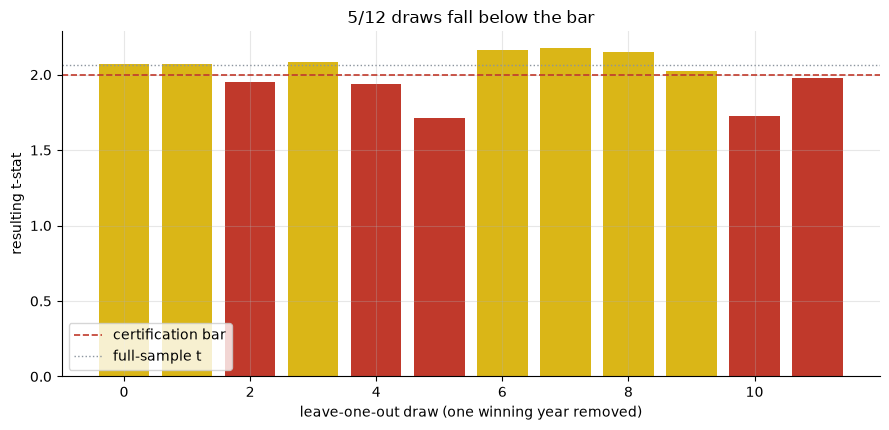

jackknife range: [1.711, 2.178]


In [5]:
if HAVE_REAL:
    x = WINNER['ar_month'].values
    years = WINNER['year'].values; countries = WINNER['country'].values
    jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
else:
    years = list(range(2010, 2026))
    rng = np.random.default_rng(708)
    jk = list(rng.uniform(R['jk_lo'], R['jk_hi'], R['jk_n']))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols = [RED if t < 2 else AMBER for t in jk]
ax.bar(range(len(jk)), jk, color=cols)
ax.axhline(2.0, ls='--', c=RED, lw=1.2, label='certification bar')
ax.axhline(R['w_mo_t'], c=GREY, lw=1, ls=':', label='full-sample t')
ax.set_xlabel('leave-one-out draw (one winning year removed)')
ax.set_ylabel('resulting t-stat'); ax.legend()
ax.set_title(f'{R["jk_below2"]}/{R["jk_n"]} draws fall below the bar')
plt.tight_layout(); plt.show()
print(f'jackknife range: [{min(jk):.3f}, {max(jk):.3f}]')

> 💡 In plain words: full-sample *t* = 2.066; jackknife range [1.711, 2.178]. **5 of 12** single-year removals push the estimate below 2. This is the textbook definition of `WEAK`: significant raw, fragile to selection — remove Denmark 2013, Sweden 2015, Portugal 2017, Switzerland 2024 or Austria 2025 and the certification is gone.

### 4e · Event anatomy — does the timing match the claimed mechanism?

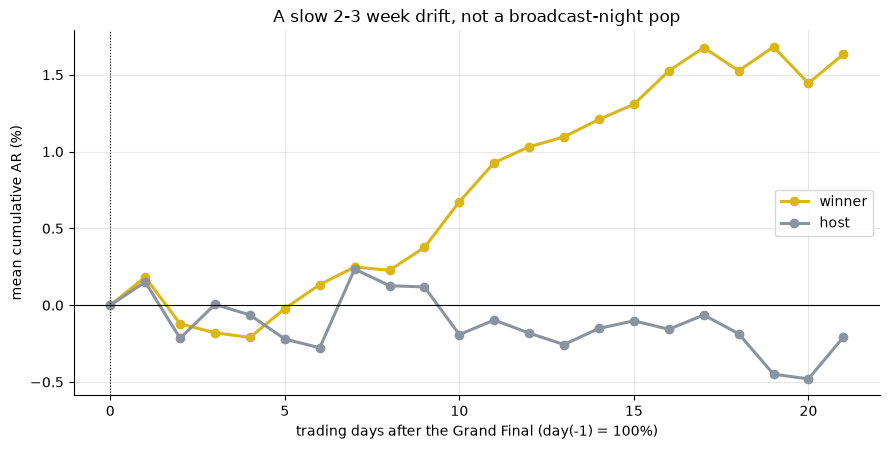

In [6]:
if HAVE_REAL:
    cp_w = st.car_path(EV, PRICES, 'winner', max_k=21)
    cp_h = st.car_path(EV, PRICES, 'host', max_k=21)
    days = list(cp_w.index); ws = list(cp_w.values*100); hs = list(cp_h.values*100)
else:
    days = sorted(R['car_w']); ws = [R['car_w'][k] for k in days]
    hs = [R['car_h'][k] for k in days]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.plot(days, ws, color=AMBER, lw=2.2, marker='o', label='winner')
ax.plot(days, hs, color=GREY, lw=2.2, marker='o', label='host')
ax.axhline(0, c='k', lw=.8); ax.axvline(0, ls=':', c='k', lw=.8)
ax.set_xlabel('trading days after the Grand Final (day(-1) = 100%)')
ax.set_ylabel('mean cumulative AR (%)')
ax.set_title('A slow 2-3 week drift, not a broadcast-night pop')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: a Saturday-broadcast national-pride mechanism predicts a fast reaction (days 0-5) that then holds — the way study 637's VIX crush resolves in a single session. Here the winner path is flat-to-negative through day 5 (-0.023%) and only accumulates its +1.634% over the following two weeks. That shape looks like ordinary drift, not an event reaction — a cross-check that argues *against* taking the winner/1-month t-stat at face value, exactly like study 637's realized-range check argued *for* its headline.

### 4f · Tradability — the honest, zero-look-ahead capture test

Enter at day(0)'s close (the first price AFTER the result is public — the final airs on a non-trading Saturday, so this is the earliest possible zero-look-ahead entry), exit day(0)+k close, 2× one-way cost × NAV per event.

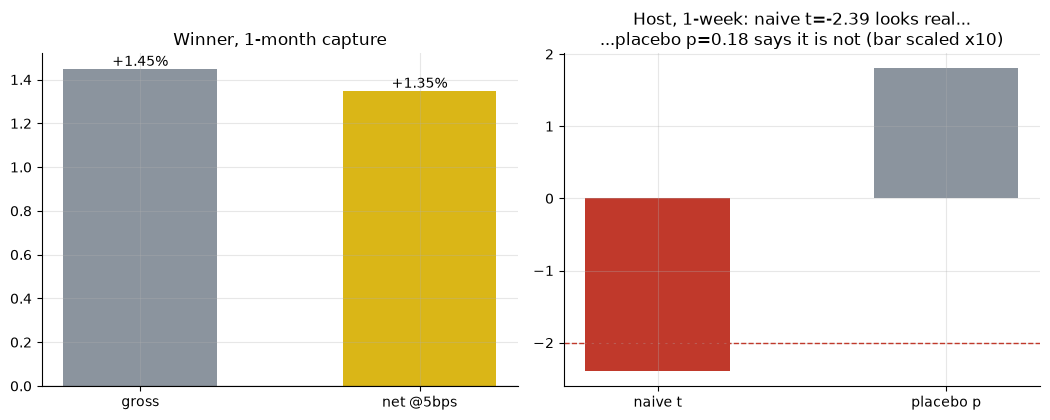

winner month capture: gross +1.45%  net +1.35%
host week capture: naive t=-2.39, placebo p=0.180


In [7]:
if HAVE_REAL:
    g = st.one_sample_t(WINNER['cap_month_gross'].values)
    n5 = st.one_sample_t(WINNER['cap_month_net'].values)
    hw = st.one_sample_t(HOST['cap_week_net'].values)
    pl_h = st.placebo_pvalue(EV[EV['role']=='host'], PRICES, 'cap_week_net',
                             k=5, entry_offset=1, cost_bps=5.0, tail='left',
                             n_seeds=4, n_draws_per_seed=200)
    g_m, n5_m, hw_t, hw_p = g['mean']*100, n5['mean']*100, hw['t'], pl_h['p_value']
else:
    g_m, n5_m, hw_t, hw_p = R['w_mo_cap_g'], R['w_mo_cap_n5'], R['h_wk_cap_t5'], R['pl_h_wk_cap_p']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(['gross', 'net @5bps'], [g_m, n5_m], color=[GREY, AMBER], width=.55)
for i, v in enumerate([g_m, n5_m]): a1.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom')
a1.axhline(0, c='k', lw=.8); a1.set_title('Winner, 1-month capture')
a2.bar(['naive t', 'placebo p'], [hw_t, hw_p*10], color=[RED, GREY], width=.5)
a2.axhline(-2, ls='--', c=RED, lw=1)
a2.set_title(f'Host, 1-week: naive t={hw_t:.2f} looks real...\n'
             f'...placebo p={hw_p:.2f} says it is not (bar scaled x10)')
plt.tight_layout(); plt.show()
print(f'winner month capture: gross {g_m:+.2f}%  net {n5_m:+.2f}%')
print(f'host week capture: naive t={hw_t:.2f}, placebo p={hw_p:.3f}')

> 💡 In plain words: the winner/1-month net capture is **+1.35%** (*t* = 1.78, placebo *p* = 0.058) — misses BOTH bars once costs and a realistic entry are applied. The host/1-week capture *looks* like a real -2.4 *t*-stat sell-the-news effect, but its own placebo (*p* = 0.180) shows that magnitude of weekly tracking-difference against `VGK` is unremarkable for these tickers — the naive stat oversold it. **H4 not supported; Tradability = MIRAGE.**

### 4g · Third axis — winning vs hosting, Welch t

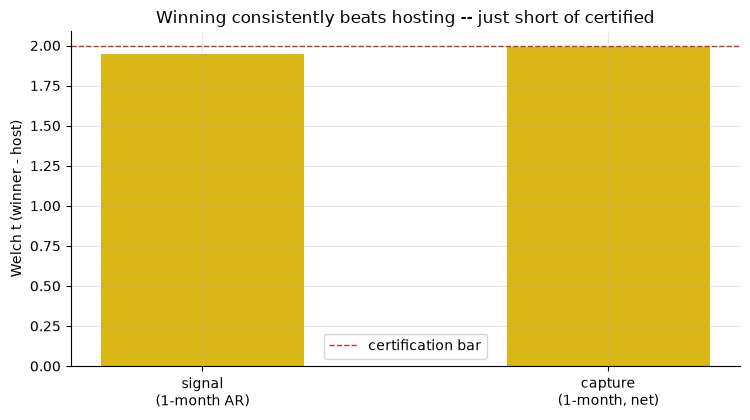

Welch t winner-host: signal +1.949  capture +1.989


In [8]:
if HAVE_REAL:
    t_sig = st.welch_t(WINNER['ar_month'].values, HOST['ar_month'].values)
    t_cap = st.welch_t(WINNER['cap_month_net'].values, HOST['cap_month_net'].values)
else:
    t_sig, t_cap = R['wh_mo_sig_t'], R['wh_mo_cap_t']
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['signal\n(1-month AR)', 'capture\n(1-month, net)'], [t_sig, t_cap],
       color=AMBER, width=.5)
ax.axhline(2, ls='--', c=RED, lw=1, label='certification bar')
ax.set_ylabel('Welch t (winner - host)')
ax.set_title('Winning consistently beats hosting -- just short of certified')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Welch t winner-host: signal {t_sig:+.3f}  capture {t_cap:+.3f}')

> 💡 In plain words: Welch *t* (winner − host) is **1.949** for the signal and **1.989** for the net capture — both a hair under 2, both pointing the same direction. If there's anything at all here, it's that *winning* carries more weight than merely *hosting* — plausible (the winner's population gets a bigger dopamine hit than the host's), but not certified. **Third axis = MIXED.**

### 4h · Faithful-engine & power control

Synthetic paired (asset, benchmark) log-return world (ρ≈0.75 correlation, like a country ETF vs a regional benchmark), a scheduled synthetic event calendar, TUNABLE planted bump. Null (bump=0) checked over **20 seeds**.

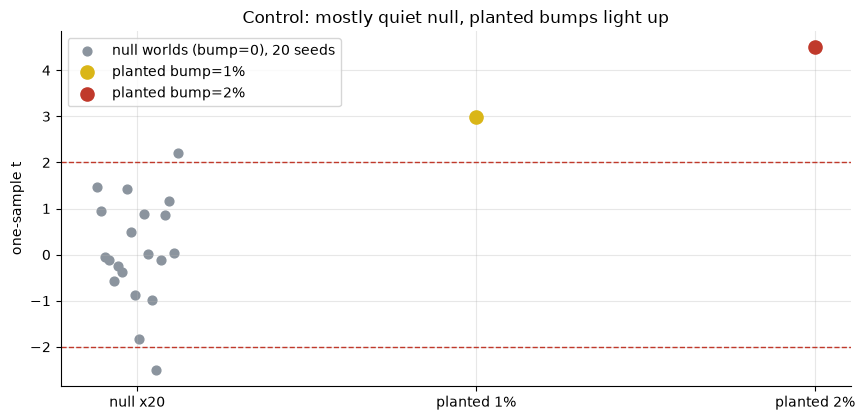

null: mean t=+0.09 (sd 1.14), |t|>=2 in 2/20 seeds
planted 1%% t=+2.98  planted 2%% t=+4.49


In [9]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=708+s, k=21)['t'] for s in range(20)])
planted1 = st.synthetic_detect(bump=0.01, seed=708, k=21)
planted2 = st.synthetic_detect(bump=0.02, seed=708, k=21)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (bump=0), 20 seeds')
ax.scatter([1], [planted1['t']], color=AMBER, s=90, zorder=5, label='planted bump=1%')
ax.scatter([2], [planted2['t']], color=RED, s=90, zorder=5, label='planted bump=2%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['null x20', 'planted 1%', 'planted 2%'])
ax.set_ylabel('one-sample t'); ax.set_title('Control: mostly quiet null, planted bumps light up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
print(f'planted 1%% t={planted1["t"]:+.2f}  planted 2%% t={planted2["t"]:+.2f}')

> 💡 In plain words: across 20 null seeds the detector averages t = +0.09 (sd 1.14) and fires at |t|≥2 in only 2/20 seeds — in line with the ordinary false-positive rate at this small n, not a bias in the detector. A planted 1% bump reads t=2.98, a planted 2% bump reads t=4.49. The machinery works; the real-tape story is genuinely this thin. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — winner/1-month AR **+1.634%**, *t* = **2.066**, placebo *p* = **0.038** — the only one of four primary cuts (winner/host × week/month) to clear the bar. Fails at 1-week (*t*=-0.06), fails for hosting (*t*=-0.40), fails pooled (*t*=1.37), and 5/12 leave-one-out draws push it below certification. The event anatomy (flat week 1, slow 2-week drift) does not match the claimed broadcast-night mechanism.
- **Tradability `MIRAGE`** — no net-of-cost, zero-look-ahead cut clears *t*≥2 with placebo confirmation; best case *t*=1.78 at *p*=0.058. A naive-looking host sell-the-news dip (*t*=-2.39) evaporates under its own placebo (*p*=0.18).
- **"Winning beats hosting?" `MIXED`** — winner point estimates beat host's at both horizons; 1-month Welch *t* = 1.95 (signal) / 1.99 (capture) — directionally consistent, not certified.

## 6 · Going further

- **The general lesson is about small-n folklore.** With only 12-13 usable events per role, ANY genuinely-random process has a good chance of producing one "significant" cut out of several tried — exactly what we found. The desk's answer is always the same: report the whole battery, not the best cut, and jackknife anything that clears the bar on a tiny sample.
- **A cleaner test would need more power.** European small-cap or consumer-discretionary sub-indices (closer to where "national mood" spending would actually show up), or extending the sample back before 2000 using local exchanges instead of US-listed ETFs, would meaningfully raise n. That's the natural sequel study.
- **Dedup map:** [235-world-cup-effect](../../235-world-cup-effect/) (the real Edmans mechanism, football elimination shocks on the S&P 500), [158-super-bowl](../../158-super-bowl/) and [709-world-series-effect](../../709-world-series-effect/) (US sports, single-market indicators), [234-olympic-year](../../234-olympic-year/) (a macro-frequency calendar effect, not an event window). None of them test a per-country abnormal-return panel keyed to a single cultural contest night — that's this study's own contribution, folklore and all.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*